In [1]:
import pandas as pd
import requests

In [2]:
ACTUAL_URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"
FORECAST_URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"

In [3]:
start_date = "2025-01-01"
end_date = "2025-01-07"

print("Fetching data from BMRS API... Please wait.")

Fetching data from BMRS API... Please wait.


In [4]:
actual_res = requests.get(ACTUAL_URL, params={"fuelType": "WIND", "settlementDateFrom": start_date, "settlementDateTo": end_date})
actual_df = pd.DataFrame([{"time": item["startTime"], "actual": item["generation"]} for item in actual_res.json()])
actual_df['time'] = pd.to_datetime(actual_df['time'], utc=True)

In [ ]:
forecast_res = requests.get(FORECAST_URL, params={"publishDateTimeFrom": "2024-12-25T00:00:00Z", "publishDateTimeTo": end_date + "T23:59:00Z"})
forecast_df = pd.DataFrame([{"time": item["startTime"], "publishTime": item["publishTime"], "forecast": item["generation"]} for item in forecast_res.json()])
forecast_df['time'] = pd.to_datetime(forecast_df['time'], utc=True)
forecast_df['publishTime'] = pd.to_datetime(forecast_df['publishTime'], utc=True)

print("Data Fetch Successful! ")
print(f"Actual Data Rows: {len(actual_df)}")
print(f"Forecast Data Rows: {len(forecast_df)}")

Data Fetch Successful! 🎉
Actual Data Rows: 336
Forecast Data Rows: 8176


In [6]:
display(actual_df.head(3))

,time,actual
0,2025-01-07 23:30:00+00:00,13454
1,2025-01-07 23:00:00+00:00,13489
2,2025-01-07 22:30:00+00:00,13405


In [7]:
import numpy as np

In [8]:
forecast_df['horizon_hours'] = (forecast_df['time'] - forecast_df['publishTime']).dt.total_seconds() / 3600

In [9]:
valid_forecasts = forecast_df[(forecast_df['horizon_hours'] >= 0) & (forecast_df['horizon_hours'] <= 48)].copy()

In [10]:
analysis_df = pd.merge(actual_df, valid_forecasts, on='time', how='inner')

In [ ]:
analysis_df['error'] = analysis_df['actual'] - analysis_df['forecast']
analysis_df['abs_error'] = analysis_df['error'].abs() 

print("Data Merged and Error Calculated! ")

Data Merged and Error Calculated! 🚀


### Part 1: Error Characteristics of the Forecast Model
Based on the absolute error calculated between the actual wind generation and the forecasted generation, we observe the following characteristics:
* **Mean Error (~1610 MW):** On average, the forecast deviates from actual generation by roughly 1610 MW.
* **Median Error (~1260 MW):** The median is significantly lower than the mean, indicating that the model is generally more accurate than the average suggests, but occasional large errors (outliers) skew the mean upward.
* **P99 Error (~5387 MW):** 99% of the time, the forecast error is below 5387 MW. This helps in understanding the worst-case prediction scenarios.

**Variation with Forecast Horizon:**
As visualized in the scatter plot, the mean absolute error increases almost linearly as the forecast horizon grows. Short-term forecasts (0-10 hours) are highly accurate (error ~1000-1200 MW), whereas long-term forecasts (40-48 hours) are much less reliable, with average errors approaching 2000+ MW.

In [12]:
mean_error = analysis_df['abs_error'].mean()
median_error = analysis_df['abs_error'].median()
p99_error = analysis_df['abs_error'].quantile(0.99)

print("\n--- OVERALL ERROR METRICS ---")
print(f"Mean Error: {mean_error:.2f} MW")
print(f"Median Error: {median_error:.2f} MW")
print(f"P99 Error (99% times error is below this): {p99_error:.2f} MW")

display(analysis_df[['time', 'horizon_hours', 'actual', 'forecast', 'abs_error']].head())


--- OVERALL ERROR METRICS ---
Mean Error: 1610.71 MW
Median Error: 1260.00 MW
P99 Error (99% times error is below this): 5387.40 MW


,time,horizon_hours,actual,forecast,abs_error
0,2025-01-07 23:00:00+00:00,0.5,13489,14725,1236
1,2025-01-07 23:00:00+00:00,4.5,13489,14492,1003
2,2025-01-07 23:00:00+00:00,7.5,13489,14504,1015
3,2025-01-07 23:00:00+00:00,11.5,13489,14764,1275
4,2025-01-07 23:00:00+00:00,13.5,13489,14784,1295


In [13]:
import matplotlib.pyplot as plt

In [14]:
horizon_error = analysis_df.groupby('horizon_hours')['abs_error'].mean().reset_index()

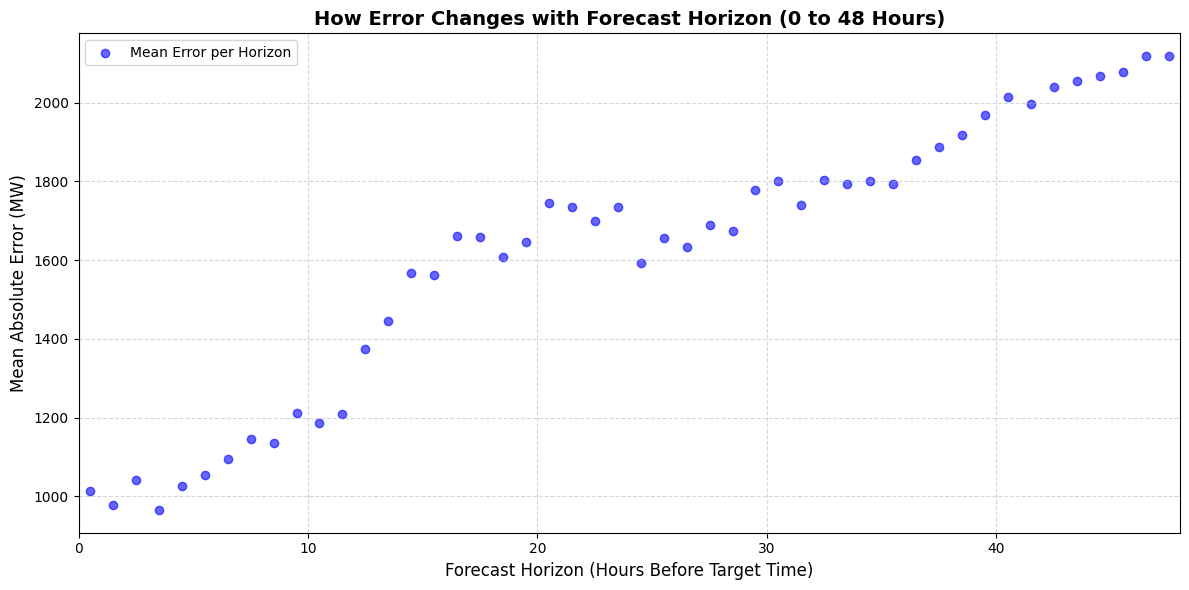

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(horizon_error['horizon_hours'], horizon_error['abs_error'], color='blue', alpha=0.6, label='Mean Error per Horizon')

plt.title('How Error Changes with Forecast Horizon (0 to 48 Hours)', fontsize=14, fontweight='bold')
plt.xlabel('Forecast Horizon (Hours Before Target Time)', fontsize=12)
plt.ylabel('Mean Absolute Error (MW)', fontsize=12)
plt.xlim(0, 48)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

### Part 2: Recommendation for Reliable Wind Power Capacity
**Question:** How many MW of wind power can we reliably expect to be available to meet the electricity demand?

**Recommendation:** We can reliably expect between **3,800 MW and 4,300 MW** of wind power.

**Reasoning Derived from First Principles:**
1. **The Flaw of Averages:** The average historical wind generation during this period was highly volatile (~10,600 MW). If we commit to the average as our "reliable" baseline, the grid will face power deficits roughly 50% of the time when wind speeds drop. Therefore, averages cannot be used for base-load reliability.
2. **Percentile-Based Reliability:** To ensure grid stability, we must plan for worst-case scenarios using percentiles:
   * **P5 Generation (3,801 MW):** 95% of the time, actual wind generation was at or above this level. This represents a highly conservative, reliable baseload equivalent.
   * **P10 Generation (4,304 MW):** 90% of the time, generation was at or above this level, representing a slightly riskier but acceptable capacity commitment.
3. **Conclusion:** Relying on ~3,800 MW ensures 95% grid stability from wind alone. Any demand above this baseline requires backup generation sources (e.g., battery storage, gas peakers) to compensate for wind intermittency.

In [ ]:



actual_generation = actual_df['actual']

mean_gen = actual_generation.mean()
min_gen = actual_generation.min()
max_gen = actual_generation.max()

p5_gen = np.percentile(actual_generation, 5) 

p10_gen = np.percentile(actual_generation, 10)

print("--- ACTUAL WIND GENERATION STATS ---")
print(f"Minimum Generated: {min_gen:.2f} MW")
print(f"Average Generated: {mean_gen:.2f} MW")
print(f"Maximum Generated: {max_gen:.2f} MW")
print("-" * 30)
print(f"P5 Generation (95% Reliability): {p5_gen:.2f} MW")
print(f"P10 Generation (90% Reliability): {p10_gen:.2f} MW")

--- ACTUAL WIND GENERATION STATS ---
Minimum Generated: 2511.00 MW
Average Generated: 10609.43 MW
Maximum Generated: 15799.00 MW
------------------------------
P5 Generation (95% Reliability): 3801.00 MW
P10 Generation (90% Reliability): 4304.50 MW
